In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path

import ssqueezepy as sq


In [72]:
wlt = sq.Wavelet('gmw')

In [74]:
wlt.config

{'gamma': 3.0,
 'beta': 60.0,
 'norm': 'bandpass',
 'order': 0.0,
 'centered_scale': False,
 'dtype': 'float32'}

In [76]:
wlt.info()

GMW L1 wavelet
	gamma=3, beta=60
	Center frequency: 2.714000   [wc_ct, (cycles*radians)]
	Time resolution:  9.498688   [std_t, non-dimensional]
	Freq resolution:  0.052639   [std_w, non-dimensional]
	Heisenberg area:  0.500001213619


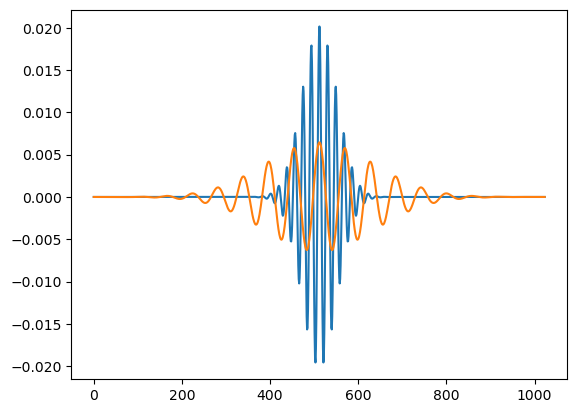

In [78]:
plt.plot(wlt.psifn(scale=8))
plt.plot(wlt.psifn(scale=25))

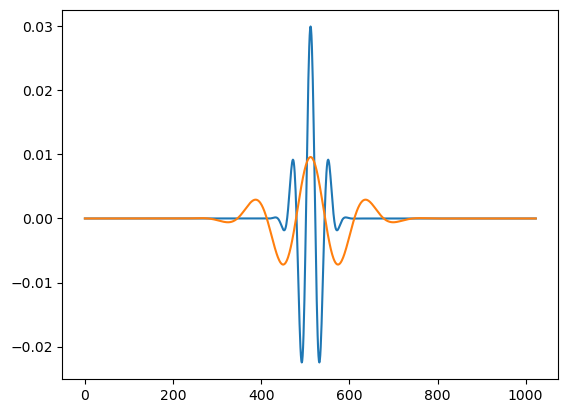

In [80]:
wlt = sq.Wavelet(('gmw', {'gamma':3, 'beta':5})) # Corresponds to MATLAB's gamma=3, TimeBandwidth=15
plt.plot(wlt.psifn(scale=8))
plt.plot(wlt.psifn(scale=25))

## Synthetic signal

In [227]:
nt = 2015

dt = 0.5
fs = 1/dt
t = np.arange(nt)*dt

# x = np.random.randn(nt)# + 
x = np.cos(2*np.pi*0.02*t)


In [241]:
wx, scales = sq.cwt(x, wavelet=wlt, fs=fs, padtype='symmetric', )
freqs = sq.experimental.scale_to_freq(scales, wavelet=wlt, N=nt, fs=fs)

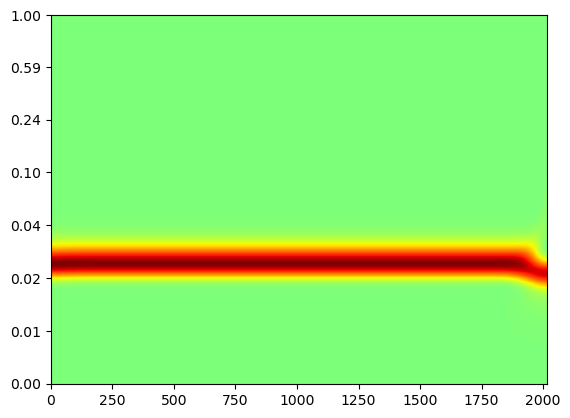

In [249]:
sq.visuals.imshow(abs(wx)**2, yticks=freqs, cmap='jet')